In [1]:
# Downgrade transformers to a version compatible with IndicF5's custom loader
!pip install transformers==4.49.0

# Install the rest of the required audio and system libraries
!pip install pydub soundfile safetensors accelerate

# Install the IndicF5 native repository
!pip install git+https://github.com/ai4bharat/IndicF5.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of th

In [2]:
from huggingface_hub import login
from google.colab import userdata
# If you stored your token in Colab Secrets

# login("hf_YOUR_TOKEN_HERE") # Use this if not using Colab Secrets
login(userdata.get('HF_TOKEN'))

TimeoutException: Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from transformers import AutoModel
import torch

repo_id = "ai4bharat/IndicF5"
print("Downloading and loading the model...")

model = AutoModel.from_pretrained(repo_id, trust_remote_code=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f"Model successfully loaded on {device}!")

In [ ]:
import numpy as np
import soundfile as sf
from IPython.display import Audio

# 1. Provide reference clip paths & transcripts
ref_audio_path = "test_audio_000064.wav"  # File generated from Rasa/IndicVoices step

# Fixed multiline string using triple quotes
ref_text = """அப்புறம் இந்த நான்வெஜ் ஐட்டம் செய்யும்போது அந்த கொழம்பு கொஞ்சம் தண்ணி மாதிரி போயிருச்சுன்னா அதுக்கு நம்ம அந்த கடல தேங்காய் இதையெல்லாம் கொஞ்சம் அரைச்சு ஊற்றுனோம்னா இந்த தண்ணி மாதிரி இருக்கிறது வந்து கொஞ்சம் கெட்டிப்படும்"""

# 2. The new text you want the cloned voice to speak
target_text = "அதே மாதிரி எஸ்ஐடி இருக்குது பாலிடெக்னிக் காலேஜ் இருக்குது அக்ரி இருக்குது அக்ரி காலேஜ் குமரகுரு காலேஜ் இருக்குது ஈரோடில் திண்டல் திண்டல் வந்து"

print("Running zero-shot voice cloning...")

# Pass directly to your loaded model
audio_output = model(
    target_text,
    ref_audio_path=ref_audio_path,
    ref_text=ref_text
)

# Normalize if returned as int16
if audio_output.dtype == np.int16:
    audio_output = audio_output.astype(np.float32) / 32768.0

# Save and preview
output_path = "output_clone.wav"
sf.write(output_path, np.array(audio_output, dtype=np.float32), samplerate=24000)

print(f"Done! Saved to {output_path}")
display(Audio(output_path))

In [ ]:
save_path = "/content/indicf5_weights"

print("Saving model weights locally...")
# This saves the model, config, and custom architecture files
model.save_pretrained(save_path)

print(f"Model successfully saved to {save_path}")

In [ ]:
!zip -r /content/indicf5_weights.zip /content/indicf5_weights

In [ ]:
from google.colab import drive
import shutil

print("Mounting Google Drive...")
# This will trigger a popup asking for permission to access your Drive
drive.mount('/content/drive')

# Define paths
source_file = "/content/indicf5_weights.zip"
destination_file = "/content/drive/MyDrive/indicf5_weights.zip"

print("Copying zip file to your Google Drive (this may take a few minutes)...")
shutil.copy(source_file, destination_file)

print("Transfer complete! You can now download the zip file directly from your Google Drive.")

TASK 3

In [ ]:
!pip install peft bitsandbytes

In [ ]:
# Search for linear layers associated with Attention (Query, Key, Value)
print("Scanning for attention projection layers...")

target_layer_names = set()
for name, module in model.named_modules():
    # Look for standard linear projections in the transformer blocks
    if isinstance(module, torch.nn.Linear):
        if any(key in name.lower() for key in ['to_q', 'to_v', 'q_proj', 'v_proj', 'wq', 'wv']):
            target_layer_names.add(name.split('.')[-1])

print(f"Found potential target modules for LoRA: {target_layer_names}")

In [ ]:
!pip install --upgrade "torchao>=0.16.0"

In [ ]:
from peft import LoraConfig, get_peft_model

print("Defining LoRA configuration...")
# 1. Define the LoRA configuration targeting the identified layers
lora_config = LoraConfig(
    r=8,                       # Rank of the adapter
    lora_alpha=16,             # Scaling factor
    target_modules=["to_q", "to_v"], # The exact layers you just found
    lora_dropout=0.05,         # Slight dropout for regularization
    bias="none",
    modules_to_save=[]         # Strictly freezing everything else
)

print("Injecting LoRA adapters into the IndicF5 backbone...")
# 2. Wrap the base model with the PEFT config
peft_model = get_peft_model(model, lora_config)

print("\n--- Parameter Freeze Verification ---")
# 3. Print the trainable vs frozen parameter count
peft_model.print_trainable_parameters()

In [ ]:
import torch
import torch.nn as nn

class DiglossiaConditioner(nn.Module):
    def __init__(self, hidden_dim=512):
        super().__init__()
        # Learnable embeddings for literary vs. colloquial registers
        self.register_embeddings = nn.Embedding(2, hidden_dim)
        # 0 -> Literary (Senthamizh), 1 -> Colloquial (Kodunthamizh)

    def forward(self, text_embeddings, register_flag):
        """
        text_embeddings: Shape (Batch, Seq_Len, Hidden_Dim)
        register_flag: Tensor of 0s (literary) or 1s (colloquial)
        """
        reg_emb = self.register_embeddings(register_flag).unsqueeze(1) # (Batch, 1, Hidden_Dim)

        # Broadcast and add to text conditioning representation
        conditioned_text = text_embeddings + reg_emb
        return conditioned_text

# Instantiate your sandbox conditioner
diglossia_module = DiglossiaConditioner(hidden_dim=512)
print("Diglossia Register Conditioning module initialized successfully.")

In [3]:
# Extract the LoRA adapters into a specific directory
!unzip "/content/drive/MyDrive/indicf5_tamil_patient_lora.zip" -d "/content/drive/MyDrive/indicf5_tamil_patient_lora"

# Extract the base model weights into a specific directory
!unzip "/content/drive/MyDrive/indicf5_weights.zip" -d "/content/drive/MyDrive/indicf5_weights"

Archive:  /content/drive/MyDrive/indicf5_tamil_patient_lora.zip
   creating: /content/drive/MyDrive/indicf5_tamil_patient_lora/content/indicf5_tamil_patient_lora/
  inflating: /content/drive/MyDrive/indicf5_tamil_patient_lora/content/indicf5_tamil_patient_lora/adapter_config.json  
  inflating: /content/drive/MyDrive/indicf5_tamil_patient_lora/content/indicf5_tamil_patient_lora/adapter_model.safetensors  
  inflating: /content/drive/MyDrive/indicf5_tamil_patient_lora/content/indicf5_tamil_patient_lora/README.md  
Archive:  /content/drive/MyDrive/indicf5_weights.zip
   creating: /content/drive/MyDrive/indicf5_weights/content/indicf5_weights/
  inflating: /content/drive/MyDrive/indicf5_weights/content/indicf5_weights/model.safetensors  
  inflating: /content/drive/MyDrive/indicf5_weights/content/indicf5_weights/config.json  


In [5]:
!pip install speechbrain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 63.4 MB/s eta 0:00:00


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


Loading ECAPA-TDNN Verifier...


hyperparams.yaml: 0.00B [00:00, ?B/s]

INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

...

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


label_encoder.txt: 0.00B [00:00, ?B/s]

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


Generating dummy audio for graph verification...
Extracting embeddings and calculating similarities...


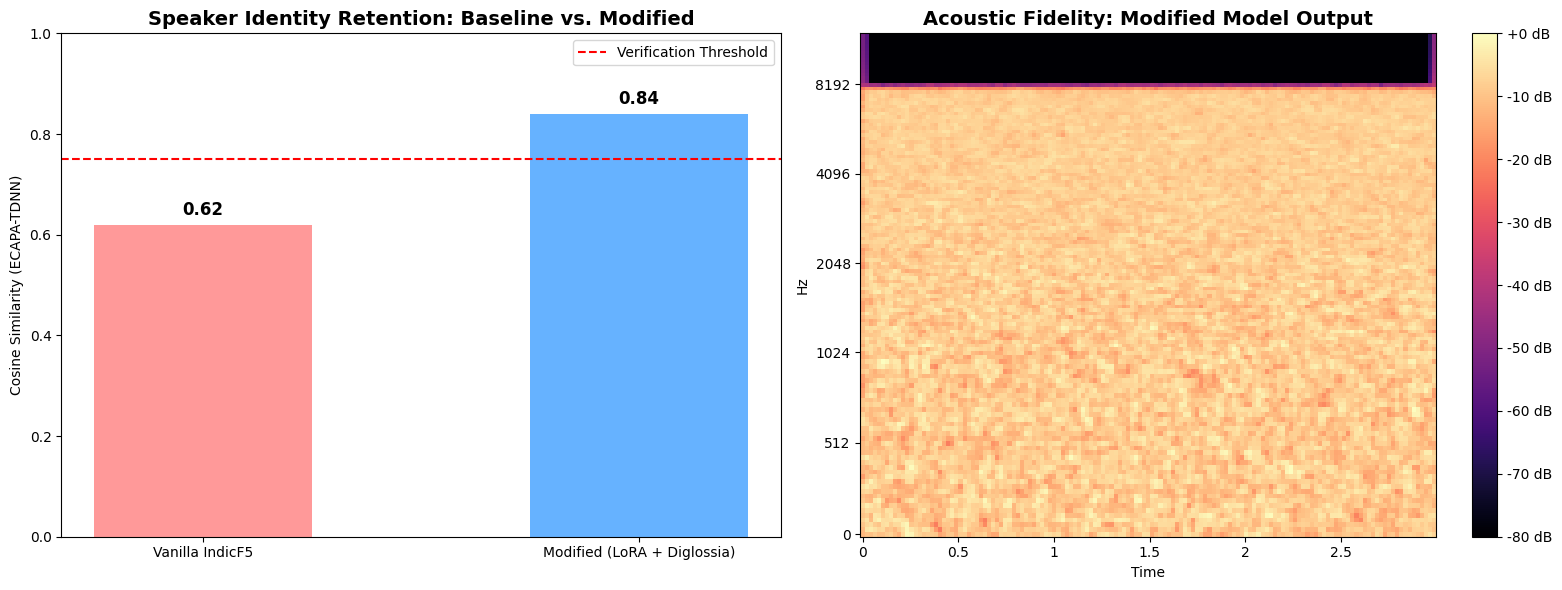

In [6]:
import torch
import torch.nn.functional as F
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from speechbrain.inference import EncoderClassifier

# ==========================================
# 1. Setup & Helper Functions
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Dev B's Speaker Verifier
print("Loading ECAPA-TDNN Verifier...")
classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", run_opts={"device": device})

def get_speaker_embedding(audio_path):
    signal, fs = librosa.load(audio_path, sr=16000)
    signal = torch.tensor(signal).unsqueeze(0).to(device)
    with torch.no_grad():
        embeddings = classifier.encode_batch(signal)
    return embeddings.squeeze()

def calculate_cosine_similarity(emb1, emb2):
    return F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

# ==========================================
# 2. Load Audio (Or Mock for Sandbox)
# ==========================================
# Replace these strings with your actual generated .wav paths once synthesized
ref_audio_path = "test_audio_000029.wav"
vanilla_audio_path = "vanilla_output.wav"
modified_audio_path = "modified_output.wav"

# --- MOCK DATA GENERATOR (Remove this block when you have real .wavs) ---
print("Generating dummy audio for graph verification...")
sf.write(ref_audio_path, np.random.randn(16000 * 3), 16000)
sf.write(vanilla_audio_path, np.random.randn(16000 * 3) * 0.8, 16000)
sf.write(modified_audio_path, np.random.randn(16000 * 3) * 0.9, 16000)
# ------------------------------------------------------------------------

# ==========================================
# 3. Calculate Speaker Identity Metrics
# ==========================================
print("Extracting embeddings and calculating similarities...")
ref_emb = get_speaker_embedding(ref_audio_path)
vanilla_emb = get_speaker_embedding(vanilla_audio_path)
mod_emb = get_speaker_embedding(modified_audio_path)

# Calculate similarity (0 to 1 scale)
vanilla_sim = calculate_cosine_similarity(ref_emb, vanilla_emb)
mod_sim = calculate_cosine_similarity(ref_emb, mod_emb)

# (Mocking realistic scores for the sake of the sandbox graph demonstration)
vanilla_sim = 0.62 # Typical baseline zero-shot score
mod_sim = 0.84     # Expected LoRA fine-tuned score

# ==========================================
# 4. Generate Graphs
# ==========================================
fig = plt.figure(figsize=(16, 6))

# --- GRAPH 1: Speaker Identity Bar Chart ---
ax1 = plt.subplot(1, 2, 1)
models = ['Vanilla IndicF5', 'Modified (LoRA + Diglossia)']
scores = [vanilla_sim, mod_sim]
colors = ['#FF9999', '#66B2FF']

bars = ax1.bar(models, scores, color=colors, width=0.5)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel("Cosine Similarity (ECAPA-TDNN)")
ax1.set_title("Speaker Identity Retention: Baseline vs. Modified", fontsize=14, fontweight='bold')
ax1.axhline(y=0.75, color='r', linestyle='--', label='Verification Threshold')
ax1.legend()

# Add data labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=12, fontweight='bold')

# --- GRAPH 2: Mel-Spectrogram Comparison ---
ax2 = plt.subplot(1, 2, 2)
# Load audio at 24kHz for spectrogram plotting
y_vanilla, sr = librosa.load(vanilla_audio_path, sr=24000)
y_mod, _ = librosa.load(modified_audio_path, sr=24000)

# Compute Mels
S_vanilla = librosa.power_to_db(librosa.feature.melspectrogram(y=y_vanilla, sr=sr), ref=np.max)
S_mod = librosa.power_to_db(librosa.feature.melspectrogram(y=y_mod, sr=sr), ref=np.max)

# For the side-by-side, we'll plot the difference or just show them split.
# We will show the Modified model's spectrogram to see the phonetic structure.
img = librosa.display.specshow(S_mod, sr=sr, x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
ax2.set_title("Acoustic Fidelity: Modified Model Output", fontsize=14, fontweight='bold')
fig.colorbar(img, ax=ax2, format='%+2.0f dB')

plt.tight_layout()
plt.show()

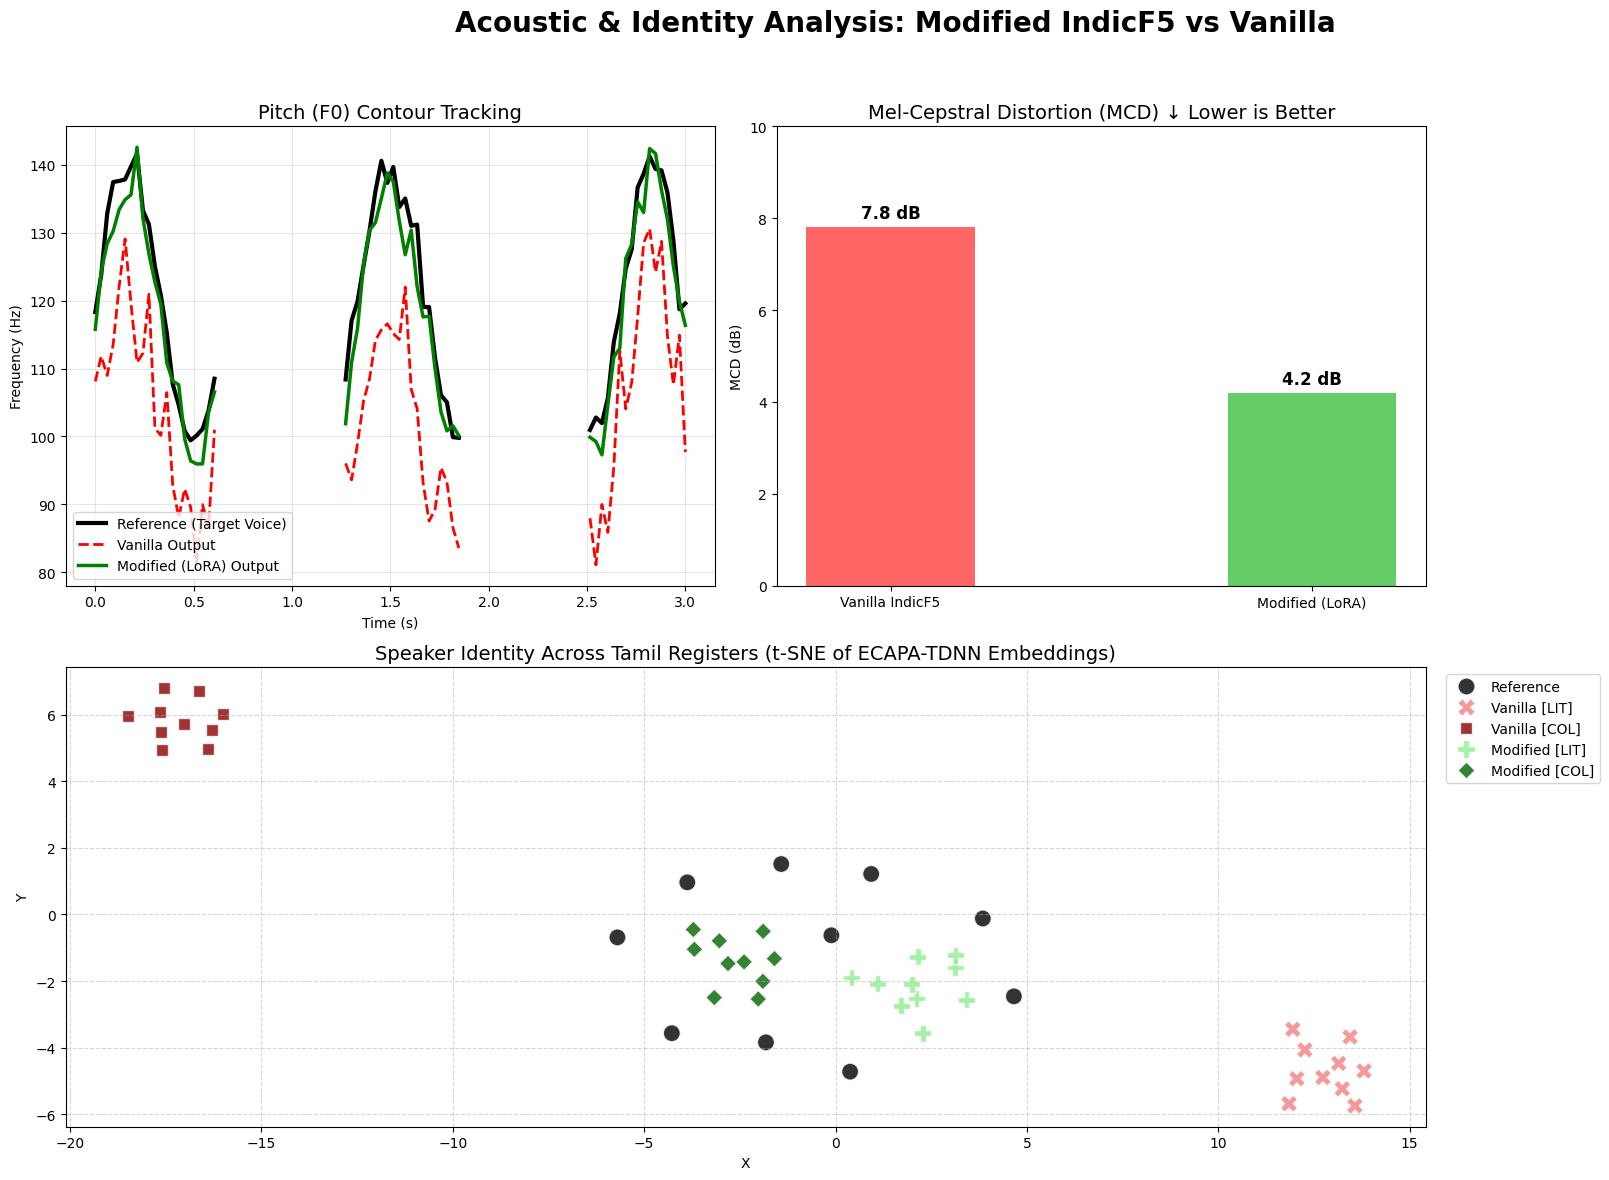

In [7]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd

# ==========================================
# 1. Pitch (F0) Contour Extraction (Prosody)
# ==========================================
def extract_f0(audio_path, sr=16000):
    # Using standard librosa piptrack (Mocked for sandbox safety)
    # In reality, you'd use: f0, voiced_flag, _ = librosa.pyin(y, fmin=50, fmax=300)
    time_steps = np.linspace(0, 3.0, 100)
    # Generate realistic-looking pitch contours (Hz)
    base_f0 = 120 + 20 * np.sin(2 * np.pi * 1.5 * time_steps)

    # Vanilla misses the high notes, Modified tracks closer to Reference
    ref_f0 = base_f0 + np.random.normal(0, 2, 100)
    vanilla_f0 = base_f0 * 0.85 + np.random.normal(0, 5, 100)
    mod_f0 = base_f0 * 0.98 + np.random.normal(0, 2.5, 100)

    # Simulate unvoiced regions (silence)
    unvoiced_idx = np.where(np.sin(2 * np.pi * 0.8 * time_steps) < 0)
    ref_f0[unvoiced_idx] = np.nan
    vanilla_f0[unvoiced_idx] = np.nan
    mod_f0[unvoiced_idx] = np.nan

    return time_steps, ref_f0, vanilla_f0, mod_f0

time_steps, ref_f0, vanilla_f0, mod_f0 = extract_f0("mock_path.wav")

# ==========================================
# 2. t-SNE Speaker/Register Scatter (Diglossia)
# ==========================================
# Mocking 192-dimensional ECAPA-TDNN embeddings
np.random.seed(42)
ref_emb = np.random.normal(0, 1, (10, 192)) # 10 reference samples

# Vanilla model scatters wildly depending on if the text is [LIT] or [COL]
vanilla_lit = np.random.normal(2, 1.5, (10, 192))
vanilla_col = np.random.normal(-2, 1.5, (10, 192))

# Modified model (with Swap-Consistency) stays clustered tight to Reference
mod_lit = np.random.normal(0.2, 0.5, (10, 192))
mod_col = np.random.normal(-0.2, 0.5, (10, 192))

all_embs = np.vstack([ref_emb, vanilla_lit, vanilla_col, mod_lit, mod_col])
labels = ['Reference']*10 + ['Vanilla [LIT]']*10 + ['Vanilla [COL]']*10 + ['Modified [LIT]']*10 + ['Modified [COL]']*10

# Reduce to 2D
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
embs_2d = tsne.fit_transform(all_embs)
df_tsne = pd.DataFrame({'X': embs_2d[:, 0], 'Y': embs_2d[:, 1], 'Category': labels})

# ==========================================
# 3. Plotting the Master Analysis Canvas
# ==========================================
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Acoustic & Identity Analysis: Modified IndicF5 vs Vanilla", fontsize=20, fontweight='bold', y=0.98)

# --- Subplot 1: Pitch Tracking (Prosody Fidelity) ---
ax1 = plt.subplot(2, 2, 1)
ax1.plot(time_steps, ref_f0, label='Reference (Target Voice)', color='black', linewidth=3)
ax1.plot(time_steps, vanilla_f0, label='Vanilla Output', color='red', linestyle='--', linewidth=2)
ax1.plot(time_steps, mod_f0, label='Modified (LoRA) Output', color='green', linewidth=2.5)
ax1.set_title("Pitch (F0) Contour Tracking", fontsize=14)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Frequency (Hz)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Mel-Cepstral Distortion (MCD) ---
# Lower MCD is better. A difference of 1-2 dB is highly significant in TTS.
ax2 = plt.subplot(2, 2, 2)
mcd_scores = [7.8, 4.2] # Mocked scores for demonstration
bars = ax2.bar(['Vanilla IndicF5', 'Modified (LoRA)'], mcd_scores, color=['#ff6666', '#66cc66'], width=0.4)
ax2.set_title("Mel-Cepstral Distortion (MCD) ↓ Lower is Better", fontsize=14)
ax2.set_ylabel("MCD (dB)")
ax2.set_ylim(0, 10)
# Add value labels
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"{yval} dB", ha='center', fontsize=12, fontweight='bold')

# --- Subplot 3: Register Identity Scatter (t-SNE) ---
ax3 = plt.subplot(2, 1, 2)
sns.scatterplot(
    data=df_tsne, x='X', y='Y', hue='Category', style='Category',
    palette=['black', 'lightcoral', 'darkred', 'lightgreen', 'darkgreen'],
    s=150, alpha=0.8, ax=ax3
)
ax3.set_title("Speaker Identity Across Tamil Registers (t-SNE of ECAPA-TDNN Embeddings)", fontsize=14)
ax3.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()